Langgraph is a library for building stateful, multi-agent applications with LLMs. StateGraph defines a graph of nodes that updates a shared state. 

- defining state using TypeDict and Annotated with reducers. 
- building a simple linear graph. 
- adding conditional edges
- running the graph and inspecting the state. 

In [ ]:
!pip install langgraph


In [3]:
from typing import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END

1. state with reducers

State is a dictionary. Each key can have associated reducer that defines how updates from nodes are combined. The default reducer simply overwrites the previous value. But for lists or other accumulative data, operator.add or custom functions can be used. 



In [5]:
class State(TypedDict):
    messages: Annotated[list[str], operator.add] # append to list
    counter: int # overwrite
    summary: str

In [10]:
def node_a(state: State) -> dict:
    print("         Node A          ")
    return {
        "messages": ["Message from A"],
        "counter": state["counter"] + 1,
        "summary": "Summary after A",
    }

def node_b(state: State) -> dict:
    print("         Node B          ")
    return {
        "messages": ["Message from B"],
        "counter": state["counter"] + 10,
        "summary": "Summary after B",
    }



In [34]:
graph = StateGraph(State)

graph.add_node("node_a", node_a)
graph.add_node("node_b", node_b)

graph.add_edge(START, "node_a")
graph.add_edge("node_a", "node_b")
graph.add_edge("node_b", END)

app = graph.compile()

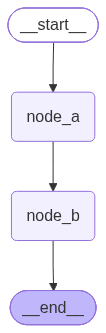

In [35]:
app

In [36]:
initial_state = {
    "messages": [],
    "counter": 0,
    "summary": "",
}

result = app.invoke(initial_state)

print("final state:", result)

         Node A          
         Node B          
final state: {'messages': ['Message from A', 'Message from B'], 'counter': 11, 'summary': 'Summary after B'}


notice:
- messages has both messages (reducer operator.add in action)
- counter and summary is overwritten. 

3. conditional edges (routing)

this node will be visited only if counter is above a threshold. 

In [37]:
def node_c(state: State) -> dict:
    print("         Node c          ")
    return {
        "messages": ["message from C"],
        "summary": "Summary after C (counter > 5)",
    }

# router function: decides whether to go node_c or end after node_b

def router_after_b(state: State) -> str:
    if state["counter"] > 5:
        return "node_c"
    else:
        return END

In [38]:
graph

In [39]:
graph.add_conditional_edges(
    "node_b",
    router_after_b,
    {
        "node_c": "node_c",
        END: END,
    },
)
graph.add_node("node_c", node_c)

graph.add_edge("node_c", END)

app = graph.compile()

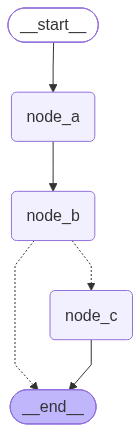

In [40]:
app

In [41]:

app.invoke({"messages": [], "counter": 0, "summary": ""})

         Node A          
         Node B          
         Node c          


{'messages': ['Message from A', 'Message from B', 'message from C'],
 'counter': 11,
 'summary': 'Summary after C (counter > 5)'}